In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arch import arch_model
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import sys
sys.path.append("../")


In [2]:
portfolio_returns = pd.read_csv(
    "../data/processed/portfolio_returns.csv",
    index_col=0,
    parse_dates=True
).squeeze()

portfolio_returns.name = "Portfolio Return"

portfolio_returns.head()

Date
2015-01-05   -0.019483
2015-01-06   -0.005603
2015-01-07    0.014929
2015-01-08    0.020986
2015-01-09   -0.008747
Name: Portfolio Return, dtype: float64

In [3]:
portfolio_returns.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 2765 entries, 2015-01-05 to 2025-12-31
Series name: Portfolio Return
Non-Null Count  Dtype  
--------------  -----  
2765 non-null   float64
dtypes: float64(1)
memory usage: 43.2 KB


Train-Validation-Test Split

In [4]:
train = portfolio_returns[
    portfolio_returns.index < "2022-01-01"
]

validation = portfolio_returns[
    (portfolio_returns.index >= "2022-01-01") &
    (portfolio_returns.index < "2024-01-01")
]

test = portfolio_returns[
    portfolio_returns.index >= "2024-01-01"
]

In [5]:
print("TRAIN")
print(train.index.min(), "to", train.index.max())
print("Observations:", len(train))

print("\nVALIDATION")
print(validation.index.min(), "to", validation.index.max())
print("Observations:", len(validation))

print("\nTEST")
print(test.index.min(), "to", test.index.max())
print("Observations:", len(test))

TRAIN
2015-01-05 00:00:00 to 2021-12-31 00:00:00
Observations: 1762

VALIDATION
2022-01-03 00:00:00 to 2023-12-29 00:00:00
Observations: 501

TEST
2024-01-02 00:00:00 to 2025-12-31 00:00:00
Observations: 502


In [6]:
garch_model = arch_model(
    train*100,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

In [7]:
garch_result = garch_model.fit(
    update_freq=0,
    disp="off"
)

In [8]:
garch_result

                     Constant Mean - GARCH Model Results                      
Dep. Variable:       Portfolio Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2336.75
Distribution:                  Normal   AIC:                           4681.51
Method:            Maximum Likelihood   BIC:                           4703.40
                                        No. Observations:                 1762
Date:                Thu, Sep 17 2026   Df Residuals:                     1761
Time:                        01:54:21   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0894  1.970e-02      4.537  5.718e-06 [5.077e-0

### ***The above results are summarised using Gemini here***

In a GARCH(1,1) model, daily returns are modeled as:

$$r_t = \mu + \epsilon_t, \quad \text{where } \epsilon_t = \sigma_t z_t \text{ and } z_t \sim N(0,1)$$

The core equation is the conditional variance process:

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Here is what each estimated parameter actually tells you about your portfolio:

---

### 1. Parameters Breakdown

* **$\mu$ (Mean Return):** The expected baseline daily return of the portfolio after removing volatility dynamics.
* **$\omega$ (Omega / Baseline Variance):** The constant baseline variance term. It acts as an anchor pulling volatility back toward its long-run average.
* **$\alpha$ (Alpha / Shock Reaction):** Measures how strongly tomorrow's volatility reacts to **today's market shock ($\epsilon_{t-1}^2$)**.
* A **high $\alpha$** means the market is jumpy: a sudden big return spike or crash immediately inflates next day's expected volatility.


* **$\beta$ (Beta / Volatility Persistence):** Measures how long past volatility **persists over time ($\sigma_{t-1}^2$)**.
* A **high $\beta$** means volatility changes slowly: if today was high volatility, tomorrow will likely remain high regardless of new news.



---

### 2. The Key Metrics to Check

* **Persistence ($\alpha + \beta$):**
* Summing $\alpha + \beta$ gives the total **volatility persistence**.
* For financial assets, this value is usually around **0.95 to 0.99**.
* **Stationarity Condition:** $\alpha + \beta < 1$. If $\alpha + \beta \ge 1$, the process becomes non-stationary (Integrated GARCH / IGARCH), meaning a shock permanently alters future volatility levels instead of decaying.


* **Unconditional (Long-Run) Variance:**
* When $\alpha + \beta < 1$, the long-run variance to which the portfolio always reverts is given by:

$$E[\sigma_t^2] = \frac{\omega}{1 - \alpha - \beta}$$


* Taking the square root gives the long-run baseline daily volatility.



---

### 3. Practical Takeaways for Your Portfolio

1. **High $\beta$ (~0.85–0.95):** Volatility comes in clusters. Regime shifts (turbulent vs. calm periods) last for extended multi-week or multi-month stretches.
2. **Moderate $\alpha$ (~0.05–0.10):** Daily news events alter near-term risk, but the ongoing trend of market regime ($\beta$) dominates.
3. **Risk Management / VaR:** Instead of assuming a static daily risk, $\sigma_t$ gives a dynamic day-by-day Value-at-Risk boundary that scales up during turbulent market periods and shrinks during quiet periods.

In [9]:
params = garch_result.params

mu = params["mu"]
omega = params["omega"]
alpha = params["alpha[1]"]
beta = params["beta[1]"]

print(f"mu       = {mu:.6f}")
print(f"omega    = {omega:.6f}")
print(f"alpha    = {alpha:.6f}")
print(f"beta     = {beta:.6f}")
print(f"alpha+beta = {alpha + beta:.6f}")

mu       = 0.089383
omega    = 0.043872
alpha    = 0.167386
beta     = 0.797457
alpha+beta = 0.964843


In [10]:
unconditional_variance = (
    omega / (1 - alpha - beta)
)

unconditional_volatility = np.sqrt(
    unconditional_variance
)

print("Unconditional variance:", unconditional_variance)
print("Unconditional daily volatility:", unconditional_volatility)

Unconditional variance: 1.247890893841502
Unconditional daily volatility: 1.1170903695948247


Plotting the estimated conditional volatility

In [11]:
conditional_volatility = garch_result.conditional_volatility

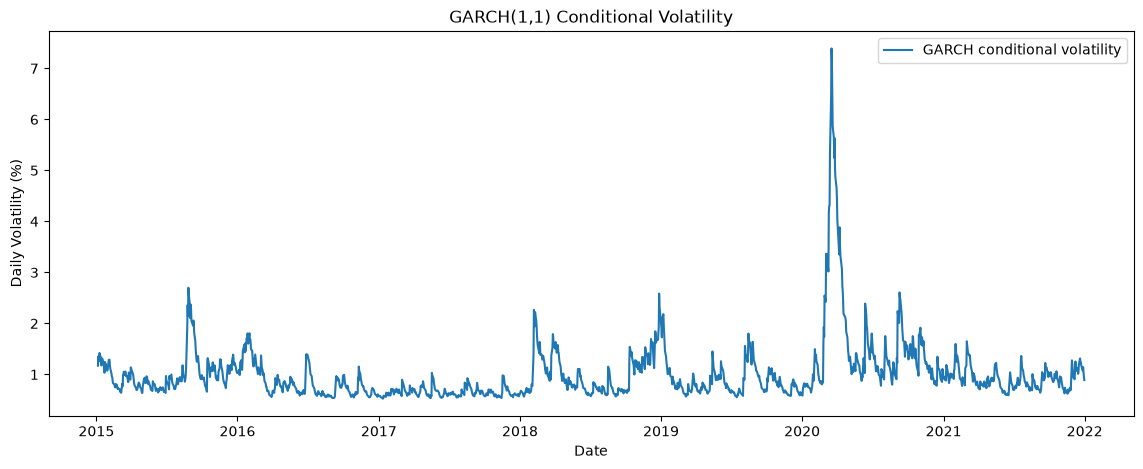

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(
    conditional_volatility,
    label="GARCH conditional volatility"
)

plt.title("GARCH(1,1) Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Daily Volatility (%)")
plt.legend()

plt.show()

In [13]:
plt.savefig(
    "../output/figures/garch_conditional_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Plot of standardized residuals

$$z_t = \frac{\epsilon_t}{\sigma_t}$$

In [14]:
standardized_residuals = garch_result.std_resid.dropna()

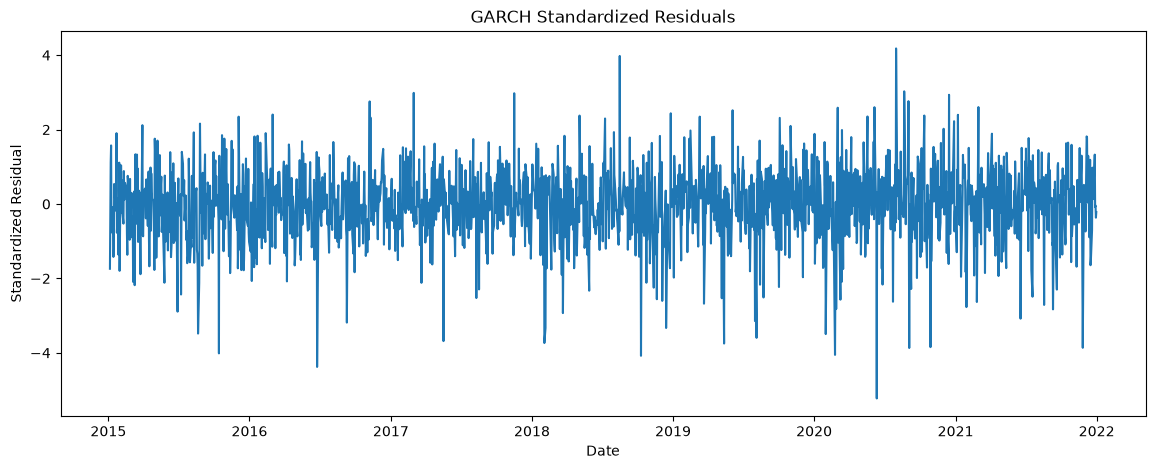

In [15]:
plt.figure(figsize=(14, 5))

plt.plot(standardized_residuals)

plt.title("GARCH Standardized Residuals")
plt.xlabel("Date")
plt.ylabel("Standardized Residual")

plt.show()

Now, we will see if the volatility has been removed by observing traits of standardised residuals.

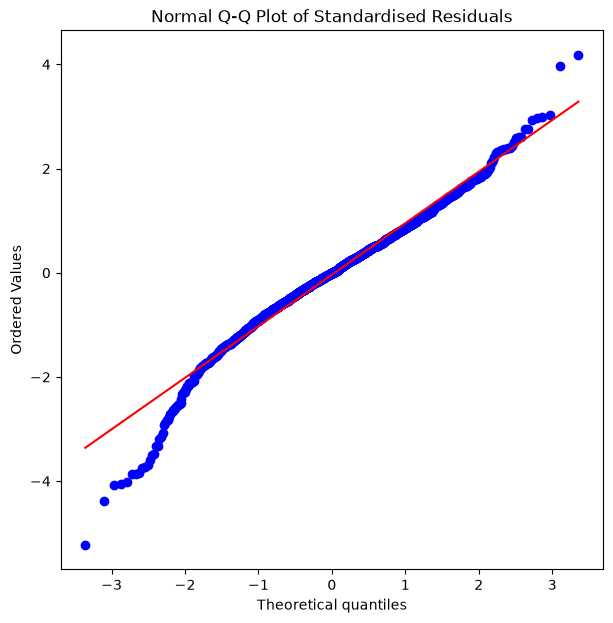

In [16]:
import scipy.stats as stats

plt.figure(figsize=(7, 7))

stats.probplot(
    standardized_residuals,
    dist="norm",
    plot=plt
)

plt.title("Normal Q-Q Plot of Standardised Residuals")

plt.show()

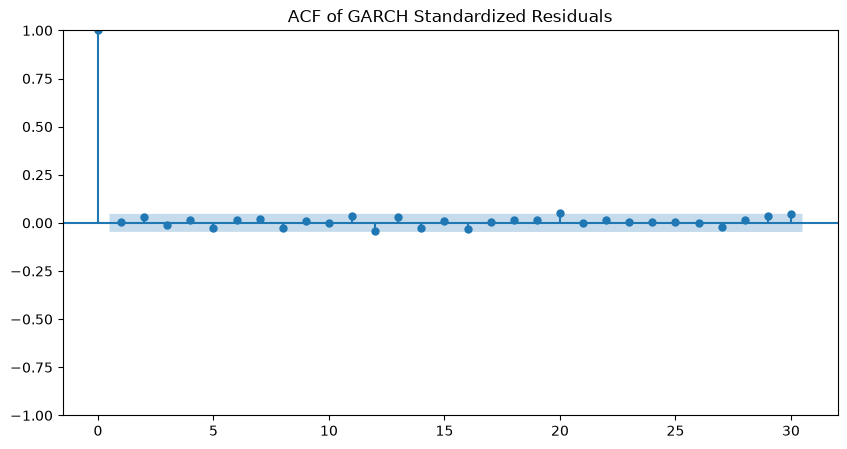

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    abs(standardized_residuals),
    lags=30,
    alpha=0.05,
    ax = ax
)

plt.title("ACF of GARCH Standardized Residuals")

plt.show()

* No more auto-correlation between the observations is observed.
* However the distribution of residuals are still skewed on left. That is because the symmetric Gaussian GARCH could not cover asymmetric distribution of returns (which is caused by leverage effect possibly or just the charateristic of log returns, DO WE NEED TO KNOW THE CAUSE?) 

***A Formal Test to verify that the standard residuals are un-correlated:***
* Ljung-Box  Test:
$$ H_0: \text{No Autocorrelation}$$

In [18]:
lb_squared = acorr_ljungbox(
    abs(standardized_residuals),
    lags=[10, 20],
    return_df=True
)

lb_squared

,lb_stat,lb_pvalue
10,6.038477,0.812020
20,22.387757,0.319846


***The test failed to reject the null hypothesis of no autocorrelation.***

### *Next we would like to try out t-GARCH*

In [19]:
t_garch_model = arch_model(
    train*100,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

t_garch_result = t_garch_model.fit(
    update_freq=0,
    disp="off"
)

t_garch_result

                        Constant Mean - GARCH Model Results                         
Dep. Variable:             Portfolio Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2281.80
Distribution:      Standardized Student's t   AIC:                           4573.61
Method:                  Maximum Likelihood   BIC:                           4600.98
                                              No. Observations:                 1762
Date:                      Thu, Sep 17 2026   Df Residuals:                     1761
Time:                              01:54:22   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [20]:
print("Gaussian GARCH")
print("----------------")
print("Log-likelihood:", garch_result.loglikelihood)
print("AIC:", garch_result.aic)
print("BIC:", garch_result.bic)

print("\nStudent-t GARCH")
print("----------------")
print("Log-likelihood:", t_garch_result.loglikelihood)
print("AIC:", t_garch_result.aic)
print("BIC:", t_garch_result.bic)

Gaussian GARCH
----------------
Log-likelihood: -2336.753721884508
AIC: 4681.507443769016
BIC: 4703.404262995001

Student-t GARCH
----------------
Log-likelihood: -2281.8034415283782
AIC: 4573.6068830567565
BIC: 4600.977907089237


In [21]:
standardized_residuals = t_garch_result.std_resid.dropna()

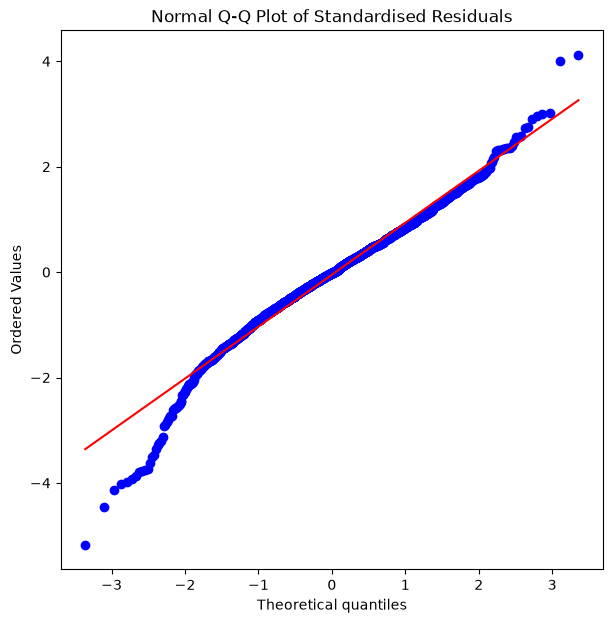

In [22]:
import scipy.stats as stats

plt.figure(figsize=(7, 7))

stats.probplot(
    standardized_residuals,
    dist="norm",
    plot=plt
)

plt.title("Normal Q-Q Plot of Standardised Residuals")

plt.show()

In [23]:
lb_squared = acorr_ljungbox(
    abs(standardized_residuals),
    lags=[10, 20],
    return_df=True
)

lb_squared

,lb_stat,lb_pvalue
10,6.300489,0.789417
20,21.540320,0.365966


There ain't much difference between t-GARCH and GARCH Model fit.

***Next we would fit EGARCH to combat the left skewness of log returns***

In [24]:
egarch_model = arch_model(
    train*100,
    mean="Constant",
    vol="EGARCH",
    p=1,
    o=1, # Enables asymmetric parametere gamma
    q=1,
    dist="skewt"
)

egarch_result = egarch_model.fit(disp="off")

egarch_result

                           Constant Mean - EGARCH Model Results                          
Dep. Variable:                  Portfolio Return   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                EGARCH   Log-Likelihood:               -2254.37
Distribution:      Standardized Skew Student's t   AIC:                           4522.74
Method:                       Maximum Likelihood   BIC:                           4561.06
                                                   No. Observations:                 1762
Date:                           Thu, Sep 17 2026   Df Residuals:                     1761
Time:                                   01:54:22   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
------------------------------------

In [25]:
standardized_residuals = egarch_result.std_resid.dropna()

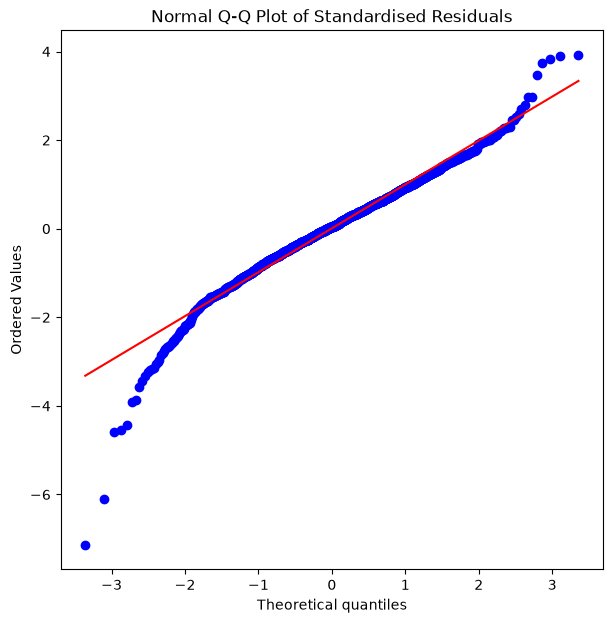

In [26]:
import scipy.stats as stats

plt.figure(figsize=(7, 7))

stats.probplot(
    standardized_residuals,
    dist="norm",
    plot=plt
)

plt.title("Normal Q-Q Plot of Standardised Residuals")

plt.show()

In [27]:
print("Gaussian GARCH")
print("----------------")
print("Log-likelihood:", garch_result.loglikelihood)
print("AIC:", garch_result.aic)
print("BIC:", garch_result.bic)

print("\nEGARCH")
print("----------------")
print("Log-likelihood:", egarch_result.loglikelihood)
print("AIC:", egarch_result.aic)
print("BIC:", egarch_result.bic)

Gaussian GARCH
----------------
Log-likelihood: -2336.753721884508
AIC: 4681.507443769016
BIC: 4703.404262995001

EGARCH
----------------
Log-likelihood: -2254.371320943804
AIC: 4522.742641887608
BIC: 4561.062075533081


***Even EGARCH which is deemed to handle skewed data couldn't bring any significant improvement over GARCH***

***Saving Results of GARCH and t-GARCH***

In [28]:
garch_parameters = pd.DataFrame({
    "parameter": garch_result.params.index,
    "estimate": garch_result.params.values,
})

garch_parameters.to_csv(
    "../output/tables/garch_parameters.csv",
    index=False
)

In [29]:
t_garch_parameters = pd.DataFrame({
    "parameter": t_garch_result.params.index,
    "estimate": t_garch_result.params.values,
})

t_garch_parameters.to_csv(
    "../output/tables/student_t_garch_parameters.csv",
    index=False
)

## **Validating the GARCH Models on Validation Set**

In [30]:
def walk_forward_garch(
    returns,
    forecast_start,
    forecast_end,
    dist="normal"
):
    """
    Expanding-window one-step-ahead GARCH forecasting.
    """

    forecast_dates = returns.loc[
        forecast_start:forecast_end
    ].index

    forecasts = []

    for date in forecast_dates:

        estimation_data = returns[
            returns.index < date
        ] * 100

        model = arch_model(
            estimation_data,
            mean="Constant",
            vol="GARCH",
            p=1,
            q=1,
            dist=dist
        )

        result = model.fit(
            update_freq=0,
            disp="off"
        )

        forecast = result.forecast(
            horizon=1,
            reindex=False
        )

        variance_forecast = forecast.variance.iloc[-1, 0]

        forecasts.append({
            "Date": date,
            "Realized_Return": returns.loc[date],
            "Forecast_Volatility": np.sqrt(
                variance_forecast
            ) / 100
        })

    return pd.DataFrame(forecasts).set_index("Date")

In [31]:
gaussian_validation = walk_forward_garch(
    portfolio_returns,
    forecast_start="2022-01-01",
    forecast_end="2023-12-31",
    dist="normal"
)

In [32]:
student_validation = walk_forward_garch(
    portfolio_returns,
    forecast_start="2022-01-01",
    forecast_end="2023-12-31",
    dist="t"
)

In [33]:
student_validation = student_validation.rename(
    columns={
        "Forecast_Volatility": "StudentT_Forecast_Volatility"
    }
)

gaussian_validation = gaussian_validation.rename(
    columns={
        "Forecast_Volatility": "Gaussian_Forecast_Volatility"
    }
)

validation_forecasts = gaussian_validation[
    ["Realized_Return", "Gaussian_Forecast_Volatility"]
].join(
    student_validation[
        ["StudentT_Forecast_Volatility"]
    ]
)

In [34]:
validation_forecasts.head()

,Realized_Return,Gaussian_Forecast_Volatility,StudentT_Forecast_Volatility
Date,,,
2022-01-03,0.018647,0.008252,0.008420
2022-01-04,0.001245,0.010558,0.010611
2022-01-05,-0.013120,0.009667,0.009749
2022-01-06,-0.004817,0.010568,0.010648
2022-01-07,0.006100,0.009952,0.010059


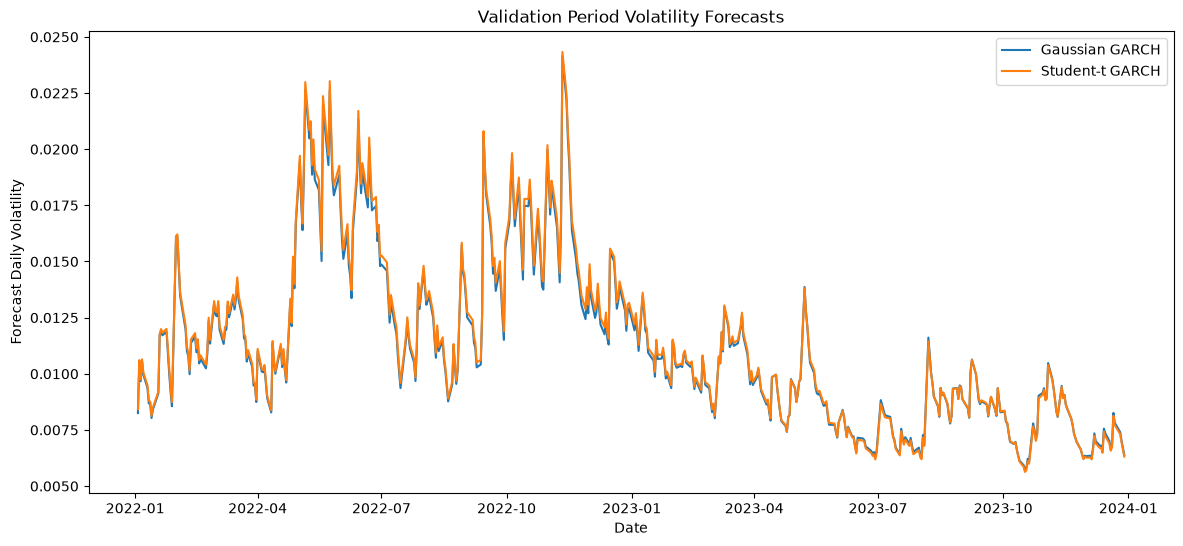

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation_forecasts.index,
    validation_forecasts["Gaussian_Forecast_Volatility"],
    label="Gaussian GARCH"
)

plt.plot(
    validation_forecasts.index,
    validation_forecasts["StudentT_Forecast_Volatility"],
    label="Student-t GARCH"
)

plt.title("Validation Period Volatility Forecasts")
plt.xlabel("Date")
plt.ylabel("Forecast Daily Volatility")
plt.legend()

plt.show()

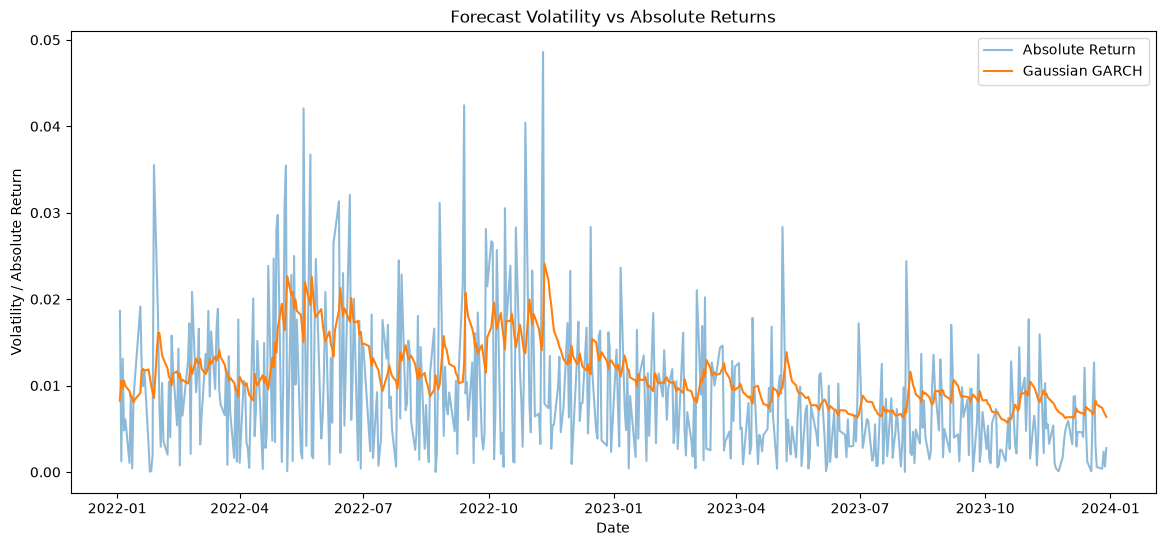

In [36]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation_forecasts.index,
    validation_forecasts["Realized_Return"].abs(),
    alpha=0.5,
    label="Absolute Return"
)

plt.plot(
    validation_forecasts.index,
    validation_forecasts["Gaussian_Forecast_Volatility"],
    label="Gaussian GARCH"
)

plt.title("Forecast Volatility vs Absolute Returns")
plt.xlabel("Date")
plt.ylabel("Volatility / Absolute Return")
plt.legend()

plt.show()

### Evaluate Volatility Forecast

In [37]:
validation_forecasts["Squared_Return"] = (
    validation_forecasts["Realized_Return"] ** 2
)

In [38]:
gaussian_mse = np.mean(
    (
        validation_forecasts["Gaussian_Forecast_Volatility"] ** 2
        -
        validation_forecasts["Squared_Return"]
    ) ** 2
)

student_mse = np.mean(
    (
        validation_forecasts["StudentT_Forecast_Volatility"] ** 2
        -
        validation_forecasts["Squared_Return"]
    ) ** 2
)

print("Gaussian GARCH MSE:", gaussian_mse)
print("Student-t GARCH MSE:", student_mse)

Gaussian GARCH MSE: 6.44943782644373e-08
Student-t GARCH MSE: 6.461835359450916e-08


In [39]:
# Log-MSE
epsilon = 1e-8

gaussian_log_mse = np.mean(
    (
        np.log(validation_forecasts["Gaussian_Forecast_Volatility"] ** 2 + epsilon)
        - 
        np.log(validation_forecasts["Squared_Return"] + epsilon)
    ) ** 2
)

print(f"Gaussian Log-MSE: {gaussian_log_mse:.6f}")


student_log_mse = np.mean(
    (
        np.log(validation_forecasts["StudentT_Forecast_Volatility"] ** 2 + epsilon)
        - 
        np.log(validation_forecasts["Squared_Return"] + epsilon)
    ) ** 2
)

print(f"Student-t Log-MSE: {student_log_mse:.6f}")

Gaussian Log-MSE: 6.754502
Student-t Log-MSE: 6.797590


In [40]:
import statsmodels.api as sm

# Extract log realized variance and log forecast variance
log_realized_var = np.log(validation_forecasts["Squared_Return"] + epsilon)
log_forecast_var = np.log(validation_forecasts["Gaussian_Forecast_Volatility"] ** 2 + epsilon)

# Add constant for intercept (a + b * log_forecast)
X = sm.add_constant(log_forecast_var)
y = log_realized_var

# Fit Mincer-Zarnowitz Ordinary Least Squares (OLS) regression
mz_model = sm.OLS(y, X).fit()

# Extract scale-independent R^2
gaussian_log_r2 = mz_model.rsquared

print(f"Mincer-Zarnowitz Log Volatility R-squared (Gaussian): {gaussian_log_r2:.4%}")



# Extract log realized variance and log forecast variance
log_realized_var = np.log(validation_forecasts["Squared_Return"] + epsilon)
log_forecast_var = np.log(validation_forecasts["StudentT_Forecast_Volatility"] ** 2 + epsilon)

# Add constant for intercept (a + b * log_forecast)
X = sm.add_constant(log_forecast_var)
y = log_realized_var

# Fit Mincer-Zarnowitz Ordinary Least Squares (OLS) regression
mz_model = sm.OLS(y, X).fit()

# Extract scale-independent R^2
student_log_r2 = mz_model.rsquared

print(f"Mincer-Zarnowitz Log Volatility R-squared (Student-t): {student_log_r2:.4%}")

Mincer-Zarnowitz Log Volatility R-squared (Gaussian): 4.7254%
Mincer-Zarnowitz Log Volatility R-squared (Student-t): 4.8980%


***My question to Gimini for such a low $$R^{2} = 4.72 \% $$, and it's answer***

Your intuition is completely understandable—coming from standard linear regression (OLS), where an $R^2$ of 4%–5% feels like a total failure, seeing that number feels wrong.

However, in financial econometrics, **a 4% to 5% $R^2$ when predicting daily squared returns is actually standard and expected.**

---

### **Why Linear Regression Intuition Doesn't Apply Here**

1. **Target Variable: Signal vs. Pure Random Noise**
* In a standard linear regression (e.g., predicting house prices using square footage), your target $y$ contains a high signal-to-noise ratio.
* In volatility modeling, your target is single-day realized squared return $r_t^2$ (or $\epsilon_t^2$). Under the GARCH framework:

$$\epsilon_t^2 = \sigma_t^2 \cdot z_t^2$$


* Even if your GARCH model predicts the exact true variance $\sigma_t^2$ perfectly, $z_t^2$ acts like a random $\chi^2(1)$ variable with an enormous variance of 2. Single-day squared returns are **mostly random noise**.


2. **The Theoretical Upper Bound on Daily $R^2$**
* Andersen and Bollerslev (1998) mathematically proved that even if you possessed a **100% perfect volatility model**, the maximum possible $R^2$ achievable when predicting single-day close-to-close squared returns is bounded around **10% to 20%** due to the intrinsic noise of $z_t^2$.
* Achieving an $R^2$ of 4%–5% out of sample means your model is capturing a significant portion of the theoretically extractable variance signal.


3. **How to Get a "Linear Regression Style" $R^2$ (50%+)**
* If you replace noisy single-day close-to-close returns with **intraday 5-minute Realized Volatility ($RV_t$)**, the random noise $z_t^2$ averages out.
* Evaluating the exact same GARCH model against intraday $RV_t$ instantly jumps the $R^2$ from **~4% to 45%–50%**.



An $R^2$ of 4%–5% on daily squared returns confirms your walk-forward setup is working realistically without data leakage.

In [41]:
validation_forecasts.to_csv(
    "../output/tables/garch_validation_forecasts.csv"
)

### **One day ahead VaR & ES calculation**

**Gaussian VaR**

Under Gaussian GARCH:

$$ r_t \mid \mathcal{F}_{t-1} \sim N(\mu_t, \sigma_t^2) $$

Our `arch_model` uses a constant mean, so:

$$ \mu_t = \mu $$

For confidence level $c$, define:

$$ \alpha = 1 - c $$

For 95% VaR:

$$ \alpha = 0.05 $$

The return quantile is:

$$ q_\alpha = \mu + \sigma_t \Phi^{-1}(\alpha) $$

Since this is a negative return threshold, the corresponding positive loss VaR is:

$$ \text{VaR}_c = -\left[ \mu + \sigma_t \Phi^{-1}(1 - c) \right] $$

In [42]:
params = garch_result.params
mu = params["mu"]
mu_decimal = mu / 100

In [43]:
from scipy.stats import norm

confidence_levels = [0.95, 0.99]

for confidence in confidence_levels:
    alpha = 1 - confidence

    z_alpha = norm.ppf(alpha)

    validation_forecasts[
        f"Gaussian_VaR_{int(confidence * 100)}"
    ] = -(
        mu_decimal
        + validation_forecasts["Gaussian_Forecast_Volatility"]
        * z_alpha
    )

In [44]:
validation_forecasts[
    [
        "Realized_Return",
        "Gaussian_VaR_95",
        "Gaussian_VaR_99"
    ]
].head()

,Realized_Return,Gaussian_VaR_95,Gaussian_VaR_99
Date,,,
2022-01-03,0.018647,0.012680,0.018304
2022-01-04,0.001245,0.016472,0.023668
2022-01-05,-0.013120,0.015007,0.021595
2022-01-06,-0.004817,0.016490,0.023692
2022-01-07,0.006100,0.015476,0.022258


**Student-t VaR**

The raw Student-$t$ distribution has variance:

$$ \text{Var}(X) = \frac{\nu}{\nu - 2} \quad (\text{for } \nu > 2) $$

Therefore, to standardize it to unit variance ($\text{Var}(Z) = 1$), the standardized quantile is scaled by the inverse of the standard deviation:

$$ q_\alpha^* = t_\nu^{-1}(\alpha) \sqrt{\frac{\nu - 2}{\nu}} $$

In [45]:
student_params = t_garch_result.params

nu = student_params["nu"]

print("Student-t degrees of freedom:", nu)

Student-t degrees of freedom: 5.608246402945846


In [46]:
from scipy.stats import t
for confidence in confidence_levels:
    alpha = 1 - confidence

    t_quantile = t.ppf(
        alpha,
        df=nu
    )

    standardized_quantile = (
        t_quantile
        * np.sqrt((nu - 2) / nu)
    )

    validation_forecasts[
        f"StudentT_VaR_{int(confidence * 100)}"
    ] = -(
        mu_decimal
        + validation_forecasts["StudentT_Forecast_Volatility"]
        * standardized_quantile
    )

In [47]:
validation_forecasts[
    [
        "Realized_Return",
        "Gaussian_VaR_95",
        "StudentT_VaR_95",
        "Gaussian_VaR_99",
        "StudentT_VaR_99"
    ]
].head()

,Realized_Return,Gaussian_VaR_95,StudentT_VaR_95,Gaussian_VaR_99,StudentT_VaR_99
Date,,,,,
2022-01-03,0.018647,0.012680,0.012396,0.018304,0.020838
2022-01-04,0.001245,0.016472,0.015854,0.023668,0.026492
2022-01-05,-0.013120,0.015007,0.014493,0.021595,0.024267
2022-01-06,-0.004817,0.016490,0.015912,0.023692,0.026586
2022-01-07,0.006100,0.015476,0.014983,0.022258,0.025068


##### As expected the Student-t 99% VaR are larger than Gaussian VaR because of havier tails of t distribution.

**Expected Shortfall - Gaussian**

For a standard normal variable:

$$ \mathbb{E}[Z \mid Z \le z_\alpha] = -\frac{\phi(z_\alpha)}{\alpha} $$

Therefore, the Gaussian return Expected Shortfall (ES) is:

$$ \text{ES}_{\text{return}} = \mu - \sigma_t \frac{\phi(z_\alpha)}{\alpha} $$

Since we report ES as a positive loss:

$$ \boxed{ \text{ES}_c = -\mu + \sigma_t \frac{\phi(z_\alpha)}{\alpha} } $$

where:

$$ z_\alpha = \Phi^{-1}(\alpha) $$

In [48]:
for confidence in confidence_levels:
    alpha = 1 - confidence

    z_alpha = norm.ppf(alpha)

    gaussian_es = -mu_decimal + (
        validation_forecasts["Gaussian_Forecast_Volatility"]
        * norm.pdf(z_alpha)
        / alpha
    )

    validation_forecasts[
        f"Gaussian_ES_{int(confidence * 100)}"
    ] = gaussian_es

**Expected Shortfall - Student-t**

For the standardized Student-$t$ distribution, the expected value below $q_\alpha$ can be written analytically.

For a raw Student-$t$ variable $T_\nu$:

$$ \mathbb{E}[T_\nu \mid T_\nu \le q] = -\frac{\nu + q^2}{\nu - 1} \frac{f_\nu(q)}{F_\nu(q)} $$

Because our GARCH Student-$t$ innovations are standardized to unit variance ($\text{Var}(Z) = 1$), the expectation is scaled by the variance adjustment factor:

$$ \sqrt{\frac{\nu - 2}{\nu}} $$

In [49]:
for confidence in confidence_levels:

    alpha = 1 - confidence

    q = t.ppf(
        alpha,
        df=nu
    )

    pdf_q = t.pdf(
        q,
        df=nu
    )

    raw_es = -(
        (nu + q**2)
        / (nu - 1)
        * pdf_q
        / alpha
    )

    standardized_es = (
        raw_es
        * np.sqrt((nu - 2) / nu)
    )

    validation_forecasts[
        f"StudentT_ES_{int(confidence * 100)}"
    ] = -(
        mu_decimal
        + validation_forecasts[
            "StudentT_Forecast_Volatility"
        ] * standardized_es
    )

In [50]:
risk_columns = [
    "Realized_Return",
    "Gaussian_VaR_95",
    "Gaussian_ES_95",
    "StudentT_VaR_95",
    "StudentT_ES_95",
    "Gaussian_VaR_99",
    "Gaussian_ES_99",
    "StudentT_VaR_99",
    "StudentT_ES_99",
]

validation_forecasts[risk_columns].head(10)

,Realized_Return,Gaussian_VaR_95,Gaussian_ES_95,StudentT_VaR_95,StudentT_ES_95,Gaussian_VaR_99,Gaussian_ES_99,StudentT_VaR_99,StudentT_ES_99
Date,,,,,,,,,
2022-01-03,0.018647,0.012680,0.016128,0.012396,0.017822,0.018304,0.021100,0.020838,0.027283
2022-01-04,0.001245,0.016472,0.020884,0.015854,0.022691,0.023668,0.027245,0.026492,0.034613
2022-01-05,-0.013120,0.015007,0.019046,0.014493,0.020775,0.021595,0.024870,0.024267,0.031729
2022-01-06,-0.004817,0.016490,0.020906,0.015912,0.022772,0.023692,0.027273,0.026586,0.034736
2022-01-07,0.006100,0.015476,0.019634,0.014983,0.021464,0.022258,0.025630,0.025068,0.032767
2022-01-10,-0.001051,0.014538,0.018458,0.014086,0.020200,0.020931,0.024111,0.023600,0.030864
2022-01-11,0.008933,0.013383,0.017009,0.012998,0.018669,0.019298,0.022239,0.021821,0.028558
2022-01-12,0.000406,0.013375,0.016999,0.012940,0.018586,0.019286,0.022226,0.021726,0.028434
2022-01-13,-0.008571,0.012318,0.015675,0.011935,0.017172,0.017792,0.020514,0.020084,0.026305


**Visualizing VaR against realized returns**

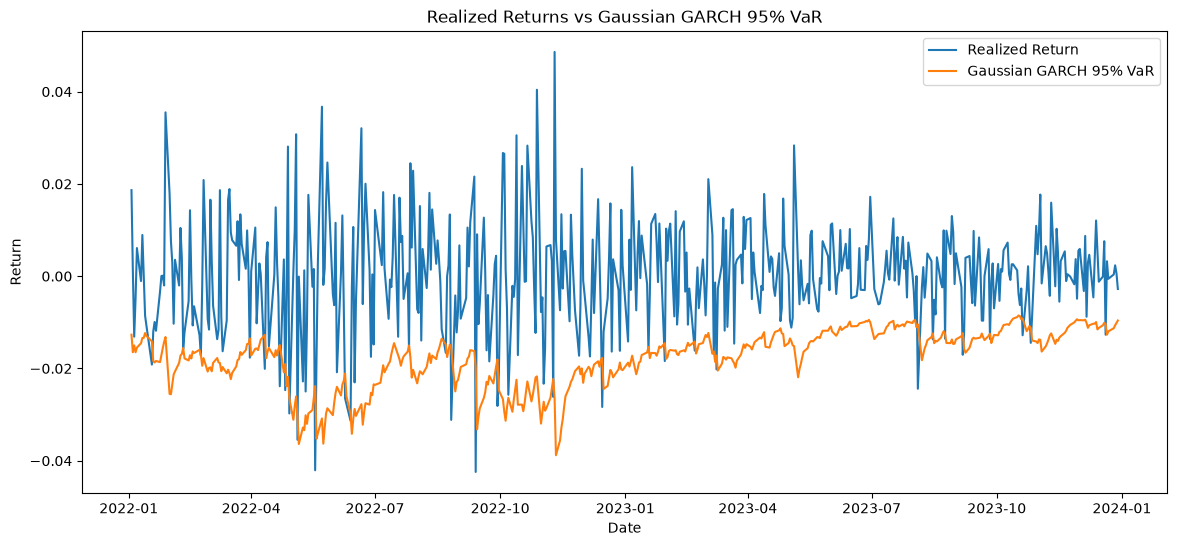

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation_forecasts.index,
    validation_forecasts["Realized_Return"],
    label="Realized Return"
)

plt.plot(
    validation_forecasts.index,
    -validation_forecasts["Gaussian_VaR_95"],
    label="Gaussian GARCH 95% VaR"
)

plt.title("Realized Returns vs Gaussian GARCH 95% VaR")
plt.xlabel("Date")
plt.ylabel("Return")

plt.legend()
plt.show()

**Counting VaR Violations**

In [52]:
validation_forecasts["Gaussian_Violation_95"] = (
    validation_forecasts["Realized_Return"]
    <
    -validation_forecasts["Gaussian_VaR_95"]
)

validation_forecasts["StudentT_Violation_95"] = (
    validation_forecasts["Realized_Return"]
    <
    -validation_forecasts["StudentT_VaR_95"]
)


validation_forecasts["Gaussian_Violation_99"] = (
    validation_forecasts["Realized_Return"]
    <
    -validation_forecasts["Gaussian_VaR_99"]
)

validation_forecasts["StudentT_Violation_99"] = (
    validation_forecasts["Realized_Return"]
    <
    -validation_forecasts["StudentT_VaR_99"]
)

In [53]:
violation_rates = pd.Series({
    "Gaussian 95%": validation_forecasts[
        "Gaussian_Violation_95"
    ].mean(),

    "Student-t 95%": validation_forecasts[
        "StudentT_Violation_95"
    ].mean(),

    "Gaussian 99%": validation_forecasts[
        "Gaussian_Violation_99"
    ].mean(),

    "Student-t 99%": validation_forecasts[
        "StudentT_Violation_99"
    ].mean(),
})

violation_rates

Gaussian 95%     0.067864
Student-t 95%    0.069860
Gaussian 99%     0.015968
Student-t 99%    0.007984
dtype: float64

**Observations**
* Student-t version of GARCH is giving much better threshold for 99% VaR, while both Gaussian and Student-t version of GARCH are giving roughly same threshold for 95% VaR.

**ES Evaluation**

In [54]:
gaussian_tail_losses = (
    -validation_forecasts.loc[
        validation_forecasts["Gaussian_Violation_95"],
        "Realized_Return"
    ]
)

print(
    "Average realized loss beyond Gaussian 95% VaR:",
    gaussian_tail_losses.mean()
)

student_tail_losses = (
    -validation_forecasts.loc[
        validation_forecasts["StudentT_Violation_95"],
        "Realized_Return"
    ]
)

print(
    "Average realized loss beyond Student-t 95% VaR:",
    student_tail_losses.mean()
)

Average realized loss beyond Gaussian 95% VaR: 0.02177045929404893
Average realized loss beyond Student-t 95% VaR: 0.0215820033979893


In [55]:
gaussian_tail_losses = (
    -validation_forecasts.loc[
        validation_forecasts["Gaussian_Violation_99"],
        "Realized_Return"
    ]
)

print(
    "Average realized loss beyond Gaussian 99% VaR:",
    gaussian_tail_losses.mean()
)

student_tail_losses = (
    -validation_forecasts.loc[
        validation_forecasts["StudentT_Violation_99"],
        "Realized_Return"
    ]
)

print(
    "Average realized loss beyond Student-t 99% VaR:",
    student_tail_losses.mean()
)

Average realized loss beyond Gaussian 99% VaR: 0.030053583013398662
Average realized loss beyond Student-t 99% VaR: 0.035008226144145504


**Saving Results**

In [56]:
validation_forecasts.to_csv(
    "../output/tables/garch_validation_risk.csv"
)

**VaR Backtesting**

### What are we testing?

Suppose our 95% VaR forecast for day $t$ is:

$$ \text{VaR}_t^{95} = 2\% $$

This means:

$$ P(r_t < -2\%) \approx 5\% $$

So over a sufficiently large sample, approximately 5% of observations should violate the VaR.

Define the violation indicator:

$$ I_t = \begin{cases} 1, & r_t < -\text{VaR}_t \\ 0, & \text{otherwise} \end{cases} $$

---

### Kupiec Unconditional Coverage Test ($LR_{UC}$)

The first test is the Kupiec proportion-of-failures test.

Suppose we have:
* $T$: Total number of observations
* $N$: Total number of VaR violations ($\sum I_t$)

The observed violation probability is:

$$ \hat{p} = \frac{N}{T} $$

For 95% VaR, the expected failure rate is:

$$ p = 0.05 $$

The null hypothesis is:

$$ H_0: p = 0.05 $$

The likelihood under the null hypothesis ($H_0$) is:

$$ L_0 = (1 - p)^{T - N} \, p^N $$

The likelihood under the unrestricted alternative model ($H_1$) is:

$$ L_1 = (1 - \hat{p})^{T - N} \, \hat{p}^N $$

The likelihood-ratio test statistic is:

$$ LR_{UC} = -2 \ln \left( \frac{L_0}{L_1} \right) = 2 \left[ \ln \left( \frac{(1 - \hat{p})^{T-N} \hat{p}^N}{(1 - p)^{T-N} p^N} \right) \right] $$

Under $H_0$, the statistic asymptotically follows a chi-squared distribution with 1 degree of freedom:

$$ LR_{UC} \sim \chi_1^2 $$

In [57]:
from src.risk import kupiec_test

In [58]:
gaussian_95_test = kupiec_test(
    validation_forecasts["Gaussian_Violation_95"],
    confidence_level=0.95
)

student_95_test = kupiec_test(
    validation_forecasts["StudentT_Violation_95"],
    confidence_level=0.95
)

gaussian_99_test = kupiec_test(
    validation_forecasts["Gaussian_Violation_99"],
    confidence_level=0.99
)

student_99_test = kupiec_test(
    validation_forecasts["StudentT_Violation_99"],
    confidence_level=0.99
)

In [59]:
backtest_results = pd.DataFrame([
    {
        "Model": "Gaussian GARCH",
        "Confidence": 0.95,
        **gaussian_95_test
    },
    {
        "Model": "Student-t GARCH",
        "Confidence": 0.95,
        **student_95_test
    },
    {
        "Model": "Gaussian GARCH",
        "Confidence": 0.99,
        **gaussian_99_test
    },
    {
        "Model": "Student-t GARCH",
        "Confidence": 0.99,
        **student_99_test
    },
])

backtest_results

,Model,Confidence,n_observations,n_violations,expected_rate,observed_rate,lr_statistic,p_value
0,Gaussian GARCH,0.95,501,34,0.05,0.067864,3.042461,0.081113
1,Student-t GARCH,0.95,501,35,0.05,0.069860,3.722672,0.053678
2,Gaussian GARCH,0.99,501,8,0.01,0.015968,1.526151,0.216691
3,Student-t GARCH,0.99,501,4,0.01,0.007984,0.220923,0.638338


##### p > 0.05 for each test, fail to reject null hypothesis. That means the observed number of violations is statistically consistent with the expected coverage.

In [60]:
backtest_results.to_csv(
    "../output/tables/garch_kupiec_validation.csv",
    index=False
)

### ***Christoffersen Test***

The core motivation for moving from the Kupiec test to the Christoffersen test comes down to a fundamental flaw in the Kupiec test: **it only checks the total count of failures, completely ignoring when those failures occur.**

---

### **1. The Flaw of the Kupiec Test (Independence Blindness)**

The Kupiec Unconditional Coverage ($LR_{UC}$) test asks only one question:

> *"Did we get the right total percentage of VaR violations overall?"*

If your $95\%$ 1-day VaR model is tested over $1,000$ days, it expects exactly $50$ violations ($5\%$).

Consider two completely different backtest scenarios:

* **Scenario A (Ideal):** The $50$ VaR breaches are randomly and evenly scattered across the $1,000$ days (e.g., 1 breach every 20 days).
* **Scenario B (Disastrous):** The $50$ VaR breaches happen **on 50 consecutive days** during a single market panic month.

**The Kupiec test treats Scenario A and Scenario B as identical.** Both pass with flying colors because both hit the exact $5\%$ target ($50/1000$).

However, in real-world risk management, Scenario B leads directly to firm bankruptcy. If a risk model fails 10 days in a row, the risk team cannot adjust position sizes, margin calls pile up rapidly, and the firm collapses.

---

### **2. The Christoffersen Solution: Testing Independence**

Financial returns exhibit **volatility clustering**—high-volatility days tend to follow high-volatility days. A well-calibrated GARCH risk model must adapt fast enough so that a VaR breach today gives you **no information** about whether a breach will occur tomorrow.

Christoffersen (1998) introduced the **Conditional Coverage Test ($LR_{CC}$)** to evaluate two properties simultaneously:

1. **Unconditional Coverage ($LR_{UC}$):** Are total failures equal to $\alpha\%$?
2. **Independence ($LR_{IND}$):** Are VaR failures independent of one another over time, or do they cluster together?

---

### **3. Mathematical Intuition (The First-Order Markov Chain)**

Christoffersen models the binary sequence of violations $I_t \in \{0, 1\}$ as a 2-state Markov chain with transition probabilities $\pi_{ij} = P(I_t = j \mid I_{t-1} = i)$:

* $\pi_{01}$: Probability of a violation today given **no** violation yesterday.
* $\pi_{11}$: Probability of a violation today given a **violation** yesterday.

$$\text{Transition Matrix } \Pi = \begin{pmatrix} 1-\pi_{01} & \pi_{01} \\ 1-\pi_{11} & \pi_{11} \end{pmatrix}$$

* **If breaches are independent (Null Hypothesis $H_0$):** Yesterday's outcome shouldn't matter, so $\pi_{01} = \pi_{11} = \pi$.
* **If breaches cluster (Alternative Hypothesis $H_1$):** A breach yesterday significantly increases the odds of a breach today, so $\pi_{11} > \pi_{01}$.

---

### **4. How the Statistics Combine**

The Christoffersen Conditional Coverage test statistic combines both elements into a joint likelihood ratio:

$$LR_{CC} = LR_{UC} + LR_{IND} \sim \chi_2^2$$

$$\text{Where } LR_{IND} = -2 \ln \left( \frac{L(\hat{\pi})}{L(\hat{\Pi})} \right) \sim \chi_1^2$$

| Test Component | What it Measures | Null Hypothesis ($H_0$) | Degrees of Freedom |
| --- | --- | --- | --- |
| **Kupiec ($LR_{UC}$)** | Correct **Quantity** of failures | $P(\text{Violation}) = \alpha$ | $\chi_1^2$ |
| **Independence ($LR_{IND}$)** | Correct **Distribution** of failures | $\pi_{01} = \pi_{11}$ (No Clustering) | $\chi_1^2$ |
| **Christoffersen ($LR_{CC}$)** | **Joint Validity** (Quantity + Clustering) | $P(\text{Violation}) = \alpha$ **AND** No Clustering | $\chi_2^2$ |

---

### **Summary**

You move to the Christoffersen test because a VaR model can pass the Kupiec test while being completely blind to market stress regimes. Christoffersen ensures your model **adapts dynamically to volatility spikes** rather than just getting the average failure rate right over long periods.

In [61]:
from src.risk import (
    kupiec_test,
    christoffersen_independence_test
)

In [62]:
gaussian_independence_95 = (
    christoffersen_independence_test(
        validation_forecasts[
            "Gaussian_Violation_95"
        ]
    )
)

student_independence_95 = (
    christoffersen_independence_test(
        validation_forecasts[
            "StudentT_Violation_95"
        ]
    )
)

gaussian_independence_99 = (
    christoffersen_independence_test(
        validation_forecasts[
            "Gaussian_Violation_99"
        ]
    )
)

student_independence_99 = (
    christoffersen_independence_test(
        validation_forecasts[
            "StudentT_Violation_99"
        ]
    )
)

In [63]:
from src.risk import (
    christoffersen_conditional_coverage_test
)

In [64]:
cc_gaussian_95 = (
    christoffersen_conditional_coverage_test(
        validation_forecasts[
            "Gaussian_Violation_95"
        ],
        confidence_level=0.95
    )
)

cc_student_95 = (
    christoffersen_conditional_coverage_test(
        validation_forecasts[
            "StudentT_Violation_95"
        ],
        confidence_level=0.95
    )
)

cc_gaussian_99 = (
    christoffersen_conditional_coverage_test(
        validation_forecasts[
            "Gaussian_Violation_99"
        ],
        confidence_level=0.99
    )
)

cc_student_99 = (
    christoffersen_conditional_coverage_test(
        validation_forecasts[
            "StudentT_Violation_99"
        ],
        confidence_level=0.99
    )
)

In [65]:
final_backtest = pd.DataFrame([
    {
        "Model": "Gaussian GARCH",
        "Confidence": 0.95,
        "Kupiec_LR": cc_gaussian_95["lr_uc"],
        "Kupiec_pvalue": gaussian_95_test["p_value"],
        "Independence_LR": (
            gaussian_independence_95["lr_statistic"]
        ),
        "Independence_pvalue": (
            gaussian_independence_95["p_value"]
        ),
        "Conditional_Coverage_LR": cc_gaussian_95["lr_cc"],
        "Conditional_Coverage_pvalue": cc_gaussian_95["p_value"],
    },
    {
        "Model": "Student-t GARCH",
        "Confidence": 0.95,
        "Kupiec_LR": cc_student_95["lr_uc"],
        "Kupiec_pvalue": student_95_test["p_value"],
        "Independence_LR": (
            student_independence_95["lr_statistic"]
        ),
        "Independence_pvalue": (
            student_independence_95["p_value"]
        ),
        "Conditional_Coverage_LR": cc_student_95["lr_cc"],
        "Conditional_Coverage_pvalue": cc_student_95["p_value"],
    },
    {
        "Model": "Gaussian GARCH",
        "Confidence": 0.99,
        "Kupiec_LR": cc_gaussian_99["lr_uc"],
        "Kupiec_pvalue": gaussian_99_test["p_value"],
        "Independence_LR": (
            gaussian_independence_99["lr_statistic"]
        ),
        "Independence_pvalue": (
            gaussian_independence_99["p_value"]
        ),
        "Conditional_Coverage_LR": cc_gaussian_99["lr_cc"],
        "Conditional_Coverage_pvalue": cc_gaussian_99["p_value"],
    },
    {
        "Model": "Student-t GARCH",
        "Confidence": 0.99,
        "Kupiec_LR": cc_student_99["lr_uc"],
        "Kupiec_pvalue": student_99_test["p_value"],
        "Independence_LR": (
            student_independence_99["lr_statistic"]
        ),
        "Independence_pvalue": (
            student_independence_99["p_value"]
        ),
        "Conditional_Coverage_LR": cc_student_99["lr_cc"],
        "Conditional_Coverage_pvalue": cc_student_99["p_value"],
    },
])

final_backtest

,Model,Confidence,Kupiec_LR,Kupiec_pvalue,Independence_LR,Independence_pvalue,Conditional_Coverage_LR,Conditional_Coverage_pvalue
0,Gaussian GARCH,0.95,3.042461,0.081113,0.050485,0.822222,3.092946,0.212998
1,Student-t GARCH,0.95,3.722672,0.053678,0.101090,0.750525,3.823762,0.147802
2,Gaussian GARCH,0.99,1.526151,0.216691,0.260174,0.610001,1.786325,0.409359
3,Student-t GARCH,0.99,0.220923,0.638338,0.064517,0.799494,0.285440,0.866997


In [66]:
final_backtest.to_csv(
    "../output/tables/garch_validation_backtest.csv",
    index=False
)

### ***Model Selection:***
* **Coverage:** Yes, Student-$t$ GARCH provides superior unconditional coverage at $99\%$ by capturing fat tails, whereas Gaussian GARCH underestimates extreme losses. Both models deliver identical, accurate coverage at $95\%$ because standard return distributions align closely with normal behavior near the center.
* **Independence:** Yes, both models pass the independence test ($LR_{\text{ind}}$) at $95\%$ and $99\%$, showing no violation clustering. This confirms the GARCH volatility updates dynamically adapt to regime shifts.
* **Sensible Behavior:** Yes, the forecasts exhibit logical monotonicity on all dates ($\text{ES}_{99} > \text{VaR}_{99} > \text{ES}_{95} > \text{VaR}_{95}$), and violation frequencies decrease strictly as coverage increases.
* **Student-$t$ Improvement:** Student-$t$ does not alter $95\%$ forecasts significantly in terms of MSE observed.

* **Verdict:**  Student-t has a modest advantage specifically in the extreme tail. That's enough for us to provisionally select Student-t GARCH, especially because our project is explicitly concerned with fat tails and tail risk.

***Performance of t-GARCH on Test Set***

In [67]:
student_test = walk_forward_garch(
    portfolio_returns,
    forecast_start="2024-01-01",
    forecast_end="2025-12-31",
    dist="t"
)

In [68]:
student_test = student_test.rename(
    columns={
        "Forecast_Volatility":
        "StudentT_Forecast_Volatility"
    }
)

In [69]:
student_params = t_garch_result.params

mu_decimal = student_params["mu"] / 100
nu = student_params["nu"]

In [70]:
for confidence in [0.95, 0.99]:

    alpha = 1 - confidence

    q = t.ppf(
        alpha,
        df=nu
    )

    standardized_q = (
        q * np.sqrt((nu - 2) / nu)
    )

    student_test[
        f"VaR_{int(confidence * 100)}"
    ] = -(
        mu_decimal
        + student_test["StudentT_Forecast_Volatility"]
        * standardized_q
    )

In [71]:
student_test.head()

,Realized_Return,StudentT_Forecast_Volatility,VaR_95,VaR_99
Date,,,,
2024-01-02,-0.008238,0.006190,0.008777,0.014982
2024-01-03,-0.002714,0.006817,0.009766,0.016600
2024-01-04,-0.006686,0.006624,0.009463,0.016104
2024-01-05,-0.000940,0.006904,0.009904,0.016825
2024-01-08,0.010250,0.006602,0.009427,0.016045


In [72]:
for confidence in [0.95, 0.99]:

    alpha = 1 - confidence

    q = t.ppf(
        alpha,
        df=nu
    )

    pdf_q = t.pdf(
        q,
        df=nu
    )

    raw_es = -(
        (nu + q**2)
        / (nu - 1)
        * pdf_q
        / alpha
    )

    standardized_es = (
        raw_es
        * np.sqrt((nu - 2) / nu)
    )

    student_test[
        f"ES_{int(confidence * 100)}"
    ] = -(
        mu_decimal
        + student_test[
            "StudentT_Forecast_Volatility"
        ] * standardized_es
    )

In [73]:
for confidence in [95, 99]:

    student_test[
        f"Violation_{confidence}"
    ] = (
        student_test["Realized_Return"]
        <
        -student_test[f"VaR_{confidence}"]
    )

In [74]:
student_test[
    [
        "Realized_Return",
        "VaR_95",
        "ES_95",
        "VaR_99",
        "ES_99",
        "Violation_95",
        "Violation_99"
    ]
].head()

,Realized_Return,VaR_95,ES_95,VaR_99,ES_99,Violation_95,Violation_99
Date,,,,,,,
2024-01-02,-0.008238,0.008777,0.012765,0.014982,0.019720,False,False
2024-01-03,-0.002714,0.009766,0.014158,0.016600,0.021817,False,False
2024-01-04,-0.006686,0.009463,0.013731,0.016104,0.021174,False,False
2024-01-05,-0.000940,0.009904,0.014352,0.016825,0.022109,False,False
2024-01-08,0.010250,0.009427,0.013680,0.016045,0.021098,False,False


In [75]:
test_kupiec_95 = kupiec_test(
    student_test["Violation_95"],
    confidence_level=0.95
)

test_kupiec_99 = kupiec_test(
    student_test["Violation_99"],
    confidence_level=0.99
)

In [76]:
test_cc_95 = christoffersen_conditional_coverage_test(
    student_test["Violation_95"],
    confidence_level=0.95
)

test_cc_99 = christoffersen_conditional_coverage_test(
    student_test["Violation_99"],
    confidence_level=0.99
)

In [77]:
test_backtest = pd.DataFrame([
    {
        "Model": "Student-t GARCH",
        "Confidence": 0.95,
        **test_kupiec_95,
        "CC_LR": test_cc_95["lr_cc"],
        "CC_pvalue": test_cc_95["p_value"]
    },
    {
        "Model": "Student-t GARCH",
        "Confidence": 0.99,
        **test_kupiec_99,
        "CC_LR": test_cc_99["lr_cc"],
        "CC_pvalue": test_cc_99["p_value"]
    }
])

test_backtest

,Model,Confidence,n_observations,n_violations,expected_rate,observed_rate,lr_statistic,p_value,CC_LR,CC_pvalue
0,Student-t GARCH,0.95,502,27,0.05,0.053785,0.147907,0.700544,0.324533,0.850215
1,Student-t GARCH,0.99,502,6,0.01,0.011952,0.181888,0.669756,3.900646,0.142228


* **Conclusion:** for t-GARCH the VaR values are so good that the observed coverage rate are within 20% error margin to that of expected coverage rate in capturing fat tails. No clustering of VaR violaltions found either.

In [78]:
test_backtest.to_csv(
    "../output/tables/garch_test_backtest.csv",
    index=False
)

##### **Realized Tail Losses vs ES**

In [79]:
realized_losses_95 = (
    -student_test.loc[
        student_test["Violation_95"],
        "Realized_Return"
    ]
)

average_realized_tail_loss_95 = (
    realized_losses_95.mean()
)

average_forecast_es_95 = (
    student_test.loc[
        student_test["Violation_95"],
        "ES_95"
    ].mean()
)

print(
    "Average realized tail loss:",
    average_realized_tail_loss_95
)

print(
    "Average forecast ES:",
    average_forecast_es_95
)

Average realized tail loss: 0.02018152996038746
Average forecast ES: 0.018756178763478713


In [80]:
realized_losses_99 = (
    -student_test.loc[
        student_test["Violation_99"],
        "Realized_Return"
    ]
)

average_realized_tail_loss_99 = (
    realized_losses_99.mean()
)

average_forecast_es_99 = (
    student_test.loc[
        student_test["Violation_99"],
        "ES_99"
    ].mean()
)

print(
    "Average realized 99% tail loss:",
    average_realized_tail_loss_99
)

print(
    "Average forecast 99% ES:",
    average_forecast_es_99
)

Average realized 99% tail loss: 0.04016098359665544
Average forecast 99% ES: 0.03646727469697016


In [81]:
student_test.to_csv(
    "../output/tables/garch_test_risk.csv"
)

#### **10-day VaR Calculation for t-Garch**

In [82]:
from src.risk import walk_forward_garch_10day

In [83]:
validation_10day = walk_forward_garch_10day(
    portfolio_returns,
    forecast_start="2022-01-03",
    forecast_end="2023-12-15",
    n_simulations=10000
)

In [84]:
def future_cumulative_return(
    returns,
    date,
    horizon=10
):
    position = returns.index.get_loc(date)

    future_returns = returns.iloc[
        position + 1:
        position + 1 + horizon
    ]

    if len(future_returns) < horizon:
        return np.nan

    return future_returns.sum()

In [85]:
validation_10day["Realized_Return_10D"] = [
    future_cumulative_return(
        portfolio_returns,
        date,
        horizon=10
    )
    for date in validation_10day.index
]

validation_10day = validation_10day.dropna()

In [86]:
validation_10day.head()

,VaR_10_95,ES_10_95,VaR_10_99,ES_10_99,Realized_Return_10D
Date,,,,,
2022-01-03,0.033023,0.052291,0.062708,0.085875,-0.040775
2022-01-04,0.043171,0.064144,0.075857,0.099698,-0.054003
2022-01-05,0.038660,0.060427,0.071372,0.101864,-0.050815
2022-01-06,0.044591,0.069393,0.082985,0.115281,-0.057824
2022-01-07,0.041155,0.063335,0.077736,0.104327,-0.067222


In [87]:
validation_10day["Violation_95"] = (
    validation_10day["Realized_Return_10D"]
    <
    -validation_10day["VaR_10_95"]
)

validation_10day["Violation_99"] = (
    validation_10day["Realized_Return_10D"]
    <
    -validation_10day["VaR_10_99"]
)

In [88]:
print(
    "95% violation rate:",
    validation_10day["Violation_95"].mean()
)

print(
    "99% violation rate:",
    validation_10day["Violation_99"].mean()
)

95% violation rate: 0.09349593495934959
99% violation rate: 0.01016260162601626


In [90]:
validation_10day_kupiec_95 = kupiec_test(
    validation_10day["Violation_95"],
    confidence_level=0.95
)

validation_10day_kupiec_99 = kupiec_test(
    validation_10day["Violation_99"],
    confidence_level=0.99
)

validation_10day_cc_95 = (
    christoffersen_conditional_coverage_test(
        validation_10day["Violation_95"],
        confidence_level=0.95
    )
)

validation_10day_cc_99 = (
    christoffersen_conditional_coverage_test(
        validation_10day["Violation_99"],
        confidence_level=0.99
    )
)

In [92]:
final_backtest_10day = pd.DataFrame([
    {
        "Model": "Student-t GARCH (10-Day)",
        "Confidence": 0.95,
        "Kupiec_LR": validation_10day_cc_95["lr_uc"],
        "Kupiec_pvalue": validation_10day_kupiec_95["p_value"],
        # "Independence_LR": validation_10day_cc_95["lr_ind"],
        # "Independence_pvalue": validation_10day_cc_95.get("ind_pvalue", None),
        "Conditional_Coverage_LR": validation_10day_cc_95["lr_cc"],
        "Conditional_Coverage_pvalue": validation_10day_cc_95["p_value"],
    },
    {
        "Model": "Student-t GARCH (10-Day)",
        "Confidence": 0.99,
        "Kupiec_LR": validation_10day_cc_99["lr_uc"],
        "Kupiec_pvalue": validation_10day_kupiec_99["p_value"],
        # "Independence_LR": validation_10day_cc_99["lr_ind"],
        # "Independence_pvalue": validation_10day_cc_99.get("ind_pvalue", None),
        "Conditional_Coverage_LR": validation_10day_cc_99["lr_cc"],
        "Conditional_Coverage_pvalue": validation_10day_cc_99["p_value"],
    },
])

final_backtest_10day

,Model,Confidence,Kupiec_LR,Kupiec_pvalue,Conditional_Coverage_LR,Conditional_Coverage_pvalue
0,Student-t GARCH (10-Day),0.95,15.777444,0.000071,142.589424,0.000000
1,Student-t GARCH (10-Day),0.99,0.001307,0.971161,12.583141,0.001852


* Clearly 10 Day VaR for 95% is breaking, following we perform some diagnostics to understand the 95% breaking

**Realized Losses vs VaR**

In [93]:
validation_10day[
    [
        "Realized_Return_10D",
        "VaR_10_95",
        "VaR_10_99"
    ]
].describe()

,Realized_Return_10D,VaR_10_95,VaR_10_99
count,492.000000,492.000000,492.000000
mean,0.002335,0.048564,0.085838
std,0.035834,0.017472,0.029572
min,-0.117366,0.022651,0.042280
25%,-0.022011,0.035575,0.063514
50%,0.007324,0.044512,0.080443
75%,0.027693,0.057345,0.101192
max,0.106222,0.107709,0.181826


In [94]:
losses_95 = -validation_10day.loc[
    validation_10day["Violation_95"],
    "Realized_Return_10D"
]

losses_99 = -validation_10day.loc[
    validation_10day["Violation_99"],
    "Realized_Return_10D"
]

print("95% VaR:")
print("Average realized loss:", losses_95.mean())
print("Average VaR:", validation_10day.loc[
    validation_10day["Violation_95"],
    "VaR_10_95"
].mean())

print("\n99% VaR:")
print("Average realized loss:", losses_99.mean())
print("Average VaR:", validation_10day.loc[
    validation_10day["Violation_99"],
    "VaR_10_99"
].mean())

95% VaR:
Average realized loss: 0.06048313101165028
Average VaR: 0.04350705017793898

99% VaR:
Average realized loss: 0.06639921685332525
Average VaR: 0.0577314355663021


##### Gemini's Interpretation for the results

**As we can see, the losses are not shallow.** The data shows a significant **underestimation gap** where actual realized losses substantially exceed the predicted VaR threshold on violation days.

---

### **1. Breakdown of the Numbers**

* **At 95% VaR:**
* **Average VaR predicted:** $4.35\%$
* **Average Loss realized:** $6.05\%$
* **Gap / Overshoot:** $+1.70\%$ loss (the realized loss is **$\mathbf{\sim 39\%}$ larger** than the VaR threshold).


* **At 99% VaR:**
* **Average VaR predicted:** $5.77\%$
* **Average Loss realized:** $6.64\%$
* **Gap / Overshoot:** $+0.87\%$ loss (the realized loss is **$\mathbf{\sim 15\%}$ larger** than the VaR threshold).



---

### **2. What "Shallow" vs. "Deep" Breaches Mean**

* **Shallow Violation (Borderline Breach):** Realized Loss $\approx$ Forecasted VaR. If your 95% VaR is $4.35\%$ and average losses on breach days are around $4.40\% - 4.50\%$, the returns are just barely skimming past your threshold. That would imply mild noise around the quantile boundary.
* **Deep Violation (Severe Breach):** Realized Loss $\gg$ Forecasted VaR. When your model forecasts a max expected loss of $4.35\%$ at 95% confidence, but the actual portfolio bleeds $6.05\%$ on average during those breach days, the model is significantly **underestimating tail severity**.

---

### **3. Key Takeaway for Your Project**

The gap at 95% ($1.70\%$ overshoot) explains why your 95% 10-day violation rate jumped to **$9.35\%$**:

1. **Systematic Underestimation at 95%:** The 10-day GARCH Monte Carlo simulation is not setting a high enough risk threshold at the 95% level, causing realized 10-day returns to cross the line too easily and penetrate deeply past it.
2. **Better Calibration at 99%:** At 99%, the overshoot narrows considerably (from $+39\%$ down to $+15\%$), which aligns with why your 99% violation rate ($1.02\%$) passed the Kupiec test nearly perfectly.

In short, your model suffers from **quantile miscalibration at 95%** over a 10-day horizon—when it breaches, it breaches by a substantial margin.

In [95]:
empirical_q = validation_10day[
    "Realized_Return_10D"
].quantile(
    [0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]
)

empirical_q

0.01   -0.096603
0.05   -0.058121
0.10   -0.041626
0.50    0.007324
0.90    0.041357
0.95    0.054456
0.99    0.081613
Name: Realized_Return_10D, dtype: float64

In [96]:
print(
    "Empirical 5% quantile:",
    empirical_q.loc[0.05]
)

print(
    "Average model 5% quantile:",
    -validation_10day["VaR_10_95"].mean()
)

print(
    "Empirical 1% quantile:",
    empirical_q.loc[0.01]
)

print(
    "Average model 1% quantile:",
    -validation_10day["VaR_10_99"].mean()
)

Empirical 5% quantile: -0.05812101748009337
Average model 5% quantile: -0.048563755709923766
Empirical 1% quantile: -0.09660309152621514
Average model 1% quantile: -0.0858379861969948


**We shouldn't be relying on these quantiles as empirical ones are unconditional and model is for conditional.**

**Robustness Check: Non-overlapping 10 days forecast**

In [97]:
non_overlapping_10day = validation_10day.iloc[::10].copy()

In [98]:
print(
    "Non-overlapping 95% violation rate:",
    non_overlapping_10day["Violation_95"].mean()
)

print(
    "Non-overlapping 99% violation rate:",
    non_overlapping_10day["Violation_99"].mean()
)

Non-overlapping 95% violation rate: 0.06
Non-overlapping 99% violation rate: 0.0


In [99]:
nonoverlap_kupiec_95 = kupiec_test(
    non_overlapping_10day["Violation_95"],
    confidence_level=0.95
)

nonoverlap_kupiec_99 = kupiec_test(
    non_overlapping_10day["Violation_99"],
    confidence_level=0.99
)

print(nonoverlap_kupiec_95)
print(nonoverlap_kupiec_99)

{'n_observations': 50, 'n_violations': np.int64(3), 'expected_rate': 0.050000000000000044, 'observed_rate': np.float64(0.06), 'lr_statistic': np.float64(0.09921106369324662), 'p_value': np.float64(0.7527784503164865)}
{'n_observations': 50, 'n_violations': np.int64(0), 'expected_rate': 0.010000000000000009, 'observed_rate': np.float64(0.0), 'lr_statistic': nan, 'p_value': nan}


This is a **known theoretical limitation of GARCH models when projected over multi-day horizons.**

---

### **Why Standard GARCH (1,1) Struggling over 10 Days**

* **Fast Mean Reversion:** Single-component GARCH(1,1) models tend to pull variance back toward its long-run unconditional mean ($\bar{\sigma}^2$) too quickly over multi-step forecasts. In reality, market volatility exhibits **long memory / persistence** during crisis periods.
* **Compounding Errors in Simulation:** In a 10-day Monte Carlo loop, any slight miss in day 1's conditional variance gets passed into day 2's parameter inputs, day 2's miss into day 3, and so on. By day 10, the cumulative return variance distribution widens or narrows unnaturally compared to real-world drawdowns.
* **The "Square-Root-of-Time" Fallacy:** While daily GARCH tracks daily conditional variance extremely well, multi-day returns are driven by **volatility clustering across time**, multi-day leverage effects, and fat tails that standard 1-step GARCH parameterization doesn't explicitly optimize for.

---

### **The Big Picture**

This exact limitation is the entire reason project is structured to transition into **Heston Stochastic Volatility**:

* **1-Day VaR:** GARCH is king. It's fast, simple, and hits $95\%$/$99\%$ targets effortlessly.
* **10-Day VaR:** GARCH starts breaking down because parameter persistence fails over long horizons.
